In [ ]:
# Ejecutar una vez al abrir el notebook; reiniciar el kernel si Jupyter lo solicita.
%pip install --quiet -r requirements.txt

# Modelo de Ising con Campo Transverso (TFIM)

En este notebook se implementa una simulación digital del **Modelo de Ising con Campo Transverso (TFIM)** utilizando una descomposición de **Suzuki-Trotter de primer orden**. El objetivo es construir el operador de evolución temporal como un circuito cuántico, ejecutarlo sobre el emulador H2 de Quantinuum mediante QNexus y comparar los resultados con la solución obtenida mediante diagonalización exacta (Exact Diagonalization, ED).

## Flujo del notebook

Este notebook realiza las siguientes etapas:

1. Definir el Hamiltoniano del TFIM.
2. Construir el circuito mediante trotterización.
3. Generar barridos sobre el tiempo de evolución $t$ y la razón $h/J$.
4. Ejecutar los circuitos en el emulador H2.
5. Recuperar los resultados para calcular observables y compararlos con la diagonalización exacta.

---

## Hamiltoniano

Para una cadena de $N$ espines, el Hamiltoniano del TFIM es

$$
\hat H =
-
J
\sum_{i=0}^{N-2}
\sigma_i^z\sigma_{i+1}^z
-
h
\sum_{i=0}^{N-1}
\sigma_i^x.
$$

Separando el Hamiltoniano en dos términos,

$$
\hat H=\hat H_{ZZ}+\hat H_X,
$$

donde

$$
\hat H_{ZZ}
=
-
J
\sum_{i=0}^{N-2}
\sigma_i^z\sigma_{i+1}^z,
$$

y

$$
\hat H_X
=
-
h
\sum_{i=0}^{N-1}
\sigma_i^x.
$$

Como ambos operadores no conmutan,

$$
[\hat H_{ZZ},\hat H_X]\neq0,
$$

la evolución temporal exacta

$$
U(t)=e^{-i\hat Ht}
$$

no puede separarse exactamente en el producto de ambas exponenciales.

---

## Aproximación de Suzuki-Trotter

Para aproximar la evolución temporal se utiliza la **fórmula producto de Suzuki-Trotter de primer orden** [1]:

$$
e^{-i\hat Ht}
=
e^{-i(\hat H_{ZZ}+\hat H_X)t}
\approx
\left(
e^{-i\hat H_X\Delta t}
e^{-i\hat H_{ZZ}\Delta t}
\right)^n,
$$

donde

$$
\Delta t=\frac{t}{n}
$$

es el tamaño del paso temporal y $n$ el número de pasos de Trotter. En el límite $n \rightarrow \infty$, esta aproximación converge a la evolución temporal exacta.

---

## Validación

La precisión de la aproximación de Trotter se evalúa comparando los observables obtenidos con **Diagonalización Exacta (ED)**, que calcula exactamente la evolución del sistema para cadenas pequeñas. En particular, este notebook compara la magnetización y las correlaciones del TFIM con la solución exacta para cuantificar el error introducido por la trotterización.

---

## Referencias

**[1]** M. Suzuki, *Generalized Trotter's Formula and Systematic Approximants of Exponential Operators and Inner Derivations with Applications to Many-Body Problems*, Communications in Mathematical Physics **51**, 183–190 (1976).

**[2]** S. Ebadi *et al.*, *Quantum Phases of Matter on a 256-Atom Programmable Quantum Simulator*, Nature **595**, 227–232 (2021).

---

## Estado inicial

Salvo que se indique lo contrario, todas las simulaciones comienzan desde el estado producto

$$
|\psi(0)\rangle = |00\cdots0\rangle.
$$

Este estado evoluciona bajo el Hamiltoniano del TFIM utilizando una descomposición de Suzuki-Trotter de primer orden.

## 1) Conexión y proyecto

Inicio de sesión en QNexus y configuración del proyecto activo.


In [14]:
import qnexus as qnx
qnx.login()
project = qnx.projects.get_or_create(
    name="Hackathon project",
)
qnx.context.set_active_project(project)

Already logged in. Tokens are valid.


## 2) Backends

`H2-1LE` (sin ruido) y `H2-Emulator` (con ruido) para dinámica y convergencia de Trotter.


In [4]:
import json
from pathlib import Path

from pytket.backends.backendresult import BackendResult


n_qbits = 8
DYNAMICS_SHOTS = 10_000
QNEXUS_RUNS_DIR = Path.cwd() / "qnexus_runs"


def prepare_run_directory(run_label, run_suffix, scan_records):
    run_root = QNEXUS_RUNS_DIR / run_label
    run_directory = run_root / run_suffix
    run_directory.mkdir(parents=True, exist_ok=False)

    (run_directory / "scan_records.json").write_text(
        json.dumps(scan_records, indent=2),
        encoding="utf-8",
    )
    (run_root / "latest_run.txt").write_text(
        str(run_directory.resolve()),
        encoding="utf-8",
    )
    return run_directory


def latest_run_directory(run_label, required=True):
    pointer = QNEXUS_RUNS_DIR / run_label / "latest_run.txt"
    if not pointer.exists():
        if required:
            raise FileNotFoundError(
                f"No existe una ejecución guardada para {run_label!r}."
            )
        return None

    run_directory = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_directory.exists():
        if required:
            raise FileNotFoundError(
                f"El directorio guardado no existe: {run_directory}"
            )
        return None
    return run_directory


def save_job_reference(job_reference, path):
    qnx.filesystem.save(
        ref=job_reference,
        path=Path(path),
        mkdir=True,
    )


def load_scan_records(run_directory):
    return json.loads(
        (Path(run_directory) / "scan_records.json").read_text(
            encoding="utf-8"
        )
    )


def recover_execution_records(run_directory):
    run_directory = Path(run_directory)
    execute_path = run_directory / "execute-job"
    if not execute_path.exists():
        raise FileNotFoundError(
            f"No existe una referencia de ejecución en {run_directory}."
        )

    execute_job = qnx.filesystem.load(path=execute_path)
    job_status = qnx.jobs.status(execute_job)
    status_value = getattr(
        job_status.status,
        "value",
        str(job_status.status),
    )
    if status_value != "COMPLETED":
        raise RuntimeError(
            f"El job no está completo: {status_value}. "
            "Revisa su estado antes de recuperar resultados."
        )

    result_refs = qnx.jobs.results(execute_job)
    scan_records = load_scan_records(run_directory)
    if len(result_refs) != len(scan_records):
        raise RuntimeError(
            f"Se encontraron {len(result_refs)} resultados para "
            f"{len(scan_records)} registros."
        )

    cache_directory = run_directory / "result_cache"
    cache_directory.mkdir(exist_ok=True)
    backend_results = []

    for index, result_ref in enumerate(
        tqdm(
            result_refs,
            desc="Recuperando resultados",
            unit="resultado",
        )
    ):
        cache_path = cache_directory / f"{index:04d}.json"
        if cache_path.exists():
            backend_result = BackendResult.from_dict(
                json.loads(cache_path.read_text(encoding="utf-8"))
            )
        else:
            backend_result = result_ref.download_result()
            temporary_path = cache_path.with_suffix(".tmp")
            temporary_path.write_text(
                json.dumps(backend_result.to_dict()),
                encoding="utf-8",
            )
            temporary_path.replace(cache_path)
        backend_results.append(backend_result)

    return [
        {**record, "backend_result": backend_result}
        for record, backend_result in zip(
            scan_records,
            backend_results,
            strict=True,
        )
    ]


## 3) Construcción del circuito trotterizado

Funciones para la evolución X, interacción ZZ y ensamblado de pasos de Trotter.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from pytket.circuit import Circuit
from pytket.extensions.offline_display import render_circuit_jupyter
from tqdm.auto import tqdm


def add_x_evolution(
    c: Circuit,
    q: int,
    h: float,
    dt: float,
) -> None:
    angle_x = (-2.0 * h * dt) / np.pi
    c.Rx(angle_x, q)


def add_zz_evolution(
    c: Circuit,
    q0: int,
    q1: int,
    J: float,
    dt: float,
) -> None:
    angle_zz = (-2.0 * J * dt) / np.pi
    c.CX(q0, q1)
    c.Rz(angle_zz, q1)
    c.CX(q0, q1)


def build_trotter_step(
    c: Circuit,
    h: float,
    J: float,
    dt: float,
    n: int,
) -> None:
    for q in range(n):
        add_x_evolution(c, q, h, dt)

    for q in range(n - 1):
        add_zz_evolution(c, q, q + 1, J, dt)


def build_trotter_circuit(
    h: float,
    J: float,
    t: float,
    steps: int,
    n_qbits: int,
) -> Circuit:
    dt = float(t) / int(steps)
    circuit = Circuit(int(n_qbits))

    for _ in range(int(steps)):
        build_trotter_step(circuit, h, J, dt, int(n_qbits))

    return circuit


## 4) Ejemplo mínimo

Circuito de 2 qubits para inspeccionar visualmente la estructura trotterizada.


In [ ]:
circuit = build_trotter_circuit(
    h=1.0,
    J=1.0,
    t=1.0,
    steps=10,
    n_qbits=2
    )

render_circuit_jupyter(circuit)

Circuito exportado en LaTeX: /Users/anotherdev/workspace/quanthathon/project/trotter_circuit_qiskit.tex


## 5) Generación del barrido TFIM

Función que genera los circuitos para cada combinación de \(h/J\) y tiempo, con metadatos de trazabilidad.


In [7]:
import datetime

def generate_tfim_trotter_scan(
    hj_ratios,
    times,
    J=1.0,
    steps=100,
    n=8,
    measure=True,
    name_prefix="tfim",
):
    """
    Genera todos los circuitos del barrido TFIM.

    El orden de salida es ratio -> tiempo. Ese orden es el que usan
    las celdas de simulacion local y las graficas posteriores.
    """
    jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H_%M_%S")
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)

    circuits = []
    scan_records = []

    for ratio_index, ratio in enumerate(ratios):
        for time_index, t in enumerate(times):
            circuit_index = len(circuits)
            circuit_name = f"{name_prefix}-{jobname_suffix}-{circuit_index}"

            circuit = build_trotter_circuit(
                h=ratio * J,
                J=J,
                t=t,
                steps=steps,
                n_qbits=n,
            )
            if measure:
                circuit.measure_all()

            circuits.append(circuit)
            scan_records.append(
                {
                    "index": circuit_index,
                    "ratio_index": ratio_index,
                    "time_index": time_index,
                    "ratio": float(ratio),
                    "time": float(t),
                    "J": float(J),
                    "steps": int(steps),
                    "dt": float(t / steps),
                    "n": int(n),
                    "name": circuit_name,
                }
            )

    return circuits, scan_records, jobname_suffix

## 6) Dinámica parametrizada por backend

Generación, compilación, ejecución, recuperación y análisis usando el backend recibido por `run_tfim_dynamics`.


In [8]:
HJ_RATIOS = np.array([0.5, 0.9, 1.0, 1.1, 2.0])
DYNAMICS_TIMES = np.linspace(0, 1, 25)[1:]
DYNAMICS_J = 1.0
DYNAMICS_STEPS = 25


def run_tfim_dynamics(
    backend,
    backend_name: str,
    run_label: str,
    *,
    force_new: bool = False,
):
    """Ejecuta el barrido completo y grafica ED frente al backend."""
    run_directory = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    execute_path = (
        None if run_directory is None else run_directory / "execute-job"
    )

    if execute_path is None or not execute_path.exists():
        compile_path = (
            None if run_directory is None else run_directory / "compile-job"
        )
        if compile_path is None or not compile_path.exists():
            circuits, scan_records, suffix = generate_tfim_trotter_scan(
                hj_ratios=HJ_RATIOS,
                times=DYNAMICS_TIMES,
                J=DYNAMICS_J,
                steps=DYNAMICS_STEPS,
                n=n_qbits,
                measure=True,
                name_prefix=f"tfim-{run_label}",
            )
            run_directory = prepare_run_directory(
                run_label, suffix, scan_records
            )
            compile_path = run_directory / "compile-job"
            circuit_refs = [
                qnx.circuits.upload(circuit=circuit, name=record["name"])
                for circuit, record in tqdm(
                    zip(circuits, scan_records, strict=True),
                    total=len(circuits),
                    desc=f"Subiendo circuitos {backend_name}",
                    unit="circuito",
                )
            ]
            compile_job = qnx.start_compile_job(
                programs=circuit_refs,
                backend_config=backend,
                optimisation_level=2,
                name=f"{run_label}-compile-{run_directory.name}",
                project=project,
            )
            save_job_reference(compile_job, compile_path)
        else:
            compile_job = qnx.filesystem.load(path=compile_path)

        qnx.jobs.wait_for(compile_job)
        compiled_circuits = [
            item.get_output() for item in qnx.jobs.results(compile_job)
        ]
        execute_job = qnx.start_execute_job(
            programs=compiled_circuits,
            backend_config=backend,
            n_shots=[DYNAMICS_SHOTS] * len(compiled_circuits),
            name=f"{run_label}-execute-{run_directory.name}",
            project=project,
        )
        execute_path = run_directory / "execute-job"
        save_job_reference(execute_job, execute_path)
        qnx.jobs.wait_for(execute_job)
    else:
        execute_job = qnx.filesystem.load(path=execute_path)
        qnx.jobs.wait_for(execute_job)
        print(f"Reutilizando ejecución {backend_name}: {run_directory}")

    execution_records = recover_execution_records(run_directory)
    dynamics_df = build_dynamics_dataframe(
        execution_records=execution_records,
        hj_ratios=HJ_RATIOS,
        times=DYNAMICS_TIMES,
        J=DYNAMICS_J,
        n=n_qbits,
    )
    csv_path = run_directory / "dynamics_observables.csv"
    dynamics_df.to_csv(csv_path, index=False)

    graph_ed_and_backend(
        dynamics_df, n=n_qbits, backend_name=backend_name
    )
    plt.show()
    graph_backend_errors(
        dynamics_df, n=n_qbits, backend_name=backend_name
    )
    plt.show()
    print(f"Resultados guardados en: {csv_path}")
    return dynamics_df


## 7) Observables del backend

Medias y errores estándar obtenidos de los counts.


In [ ]:
from matplotlib.lines import Line2D


OBSERVABLE_KEYS = ("mz", "mz2", "czz")
CONFIDENCE_Z = 1.96


def _z_observable_values(bitstring, n: int) -> np.ndarray:
    bits = np.asarray(tuple(bitstring), dtype=int)

    z_values = 1 - 2 * bits # Z|0> = |0>, Z|1> = -|1> tal que, z_values = 1 para |0> y z_values = -1 para |1>
    mz = np.mean(z_values)
    mz2 = mz**2
    czz = np.mean([z_values[q] * z_values[q + 1] for q in range(n - 1)]) # Correlación ZZ entre qubits adyacentes
    return np.array([mz, mz2, czz], dtype=float)


def z_observables_from_probability_result(
    backend_result,
    n: int,
) -> tuple[float, float, float]:
    """Observables exactos desde un resultado de estado de AerState."""
    probabilities = (
        backend_result
        .get_probability_distribution()
        .as_dict()
    )

    means = np.zeros(3, dtype=float)
    for bitstring, probability in probabilities.items():
        means += float(probability) * _z_observable_values(bitstring, n) # probabilidad ponderada de los observables Z 

    return tuple(float(value) for value in means)


def z_observables_from_empirical_result(
    backend_result,
    n: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Medias y errores estándar desde counts del backend."""
    counts = (
        backend_result
        .get_empirical_distribution()
        .as_counter()
    )
    total_shots = int(sum(counts.values()))
    if total_shots < 1:
        raise ValueError("El resultado empírico no contiene shots.")

    weighted_sum = np.zeros(3, dtype=float)
    weighted_square_sum = np.zeros(3, dtype=float)

    for bitstring, count in counts.items():
        values = _z_observable_values(bitstring, n)
        weighted_sum += int(count) * values
        weighted_square_sum += int(count) * values**2

    means = weighted_sum / total_shots

    sample_variances = (
        weighted_square_sum - total_shots * means**2
    ) / (total_shots - 1) 

    standard_errors = np.sqrt(
        np.maximum(sample_variances, 0.0) / total_shots
    )

    return means, standard_errors


def empirical_observables_grid(
    execution_records,
    hj_ratios,
    times,
    n: int,
):
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)
    shape = (len(ratios), len(times))

    means = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }
    standard_errors = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }

    for record in execution_records:
        ratio_matches = np.flatnonzero(
            np.isclose(ratios, record["ratio"])
        )
        time_matches = np.flatnonzero(
            np.isclose(times, record["time"])
        )
        if len(ratio_matches) != 1 or len(time_matches) != 1:
            raise ValueError(
                "No se pudo asociar de forma única el resultado con el barrido."
            )

        values, errors = z_observables_from_empirical_result(
            record["backend_result"],
            n,
        )
        i = int(ratio_matches[0])
        j = int(time_matches[0])

        for observable_index, key in enumerate(OBSERVABLE_KEYS):
            means[key][i, j] = values[observable_index]
            standard_errors[key][i, j] = errors[observable_index]

    return ratios, times, means, standard_errors


def graph_backend_observables_in_time(
    dynamics_df,
    n: int,
    backend_name: str,
):
    ratios = np.sort(dynamics_df["h_over_J"].unique())

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ratios)))
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t) \rangle$", r"$M_z$"),
        ("czz", axes[1], r"$\langle Z_i Z_{i+1}(t) \rangle$", r"$C_{ZZ}$"),
        ("mz2", axes[2], r"$\langle M_z^2(t) \rangle$", r"$M_z^2$"),
    ]

    for key, axis, ylabel, title in plot_specs:
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            axis.plot(
                ratio_data["time"],
                ratio_data["ed_value"],
                color=color,
                linewidth=2,
            )
            axis.errorbar(
                ratio_data["time"],
                ratio_data["backend_value"],
                yerr=CONFIDENCE_Z * ratio_data["standard_error"],
                color=color,
                fmt="o",
                markersize=4,
                markerfacecolor="white",
                markeredgewidth=1,
                capsize=4,
                capthick=1.25,
                elinewidth=1.25,
                alpha=1.0,
                zorder=3,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        axis.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")

    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="ED",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            linestyle="none",
            markersize=4,
            markerfacecolor="white",
            label=f"{backend_name} (IC 95 %)",
        ),
    ]
    fig.legend(
        handles=ratio_handles + method_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    fig.suptitle(
        f"Dinámica TFIM: ED vs {backend_name}, N={n}, "
        f"{DYNAMICS_SHOTS:,} shots"
    )

    return fig, axes


## 8) Diagonalización exacta y gráficas comparativas


In [ ]:
from functools import lru_cache

import pandas as pd
from scipy.linalg import eigh


OBSERVABLE_KEYS = ("mz", "mz2", "czz")


@lru_cache(maxsize=None)
def exact_tfim_model(h: float, J: float, n: int):
    """Diagonaliza el TFIM abierto y construye observables diagonales en Z."""
    h = float(h)
    J = float(J)
    n = int(n)
    if n < 2:
        raise ValueError("CZZ requiere al menos dos qubits.")

    dimension = 2**n
    basis = np.arange(dimension, dtype=np.uint64)
    positions = np.arange(n, dtype=np.uint64)
    bits = ((basis[:, None] >> positions) & 1).astype(int)
    z_values = 1 - 2 * bits

    mz_values = np.mean(z_values, axis=1)
    mz2_values = mz_values**2
    czz_values = np.mean(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )
    zz_sum = np.sum(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )

    hamiltonian = np.diag(-J * zz_sum).astype(complex)
    rows = np.arange(dimension)
    for site in range(n):
        flipped = basis ^ np.uint64(1 << site)
        hamiltonian[rows, flipped.astype(int)] -= h

    eigenvalues, eigenvectors = eigh(hamiltonian)
    initial_state = np.zeros(dimension, dtype=complex)
    initial_state[0] = 1.0
    initial_coefficients = eigenvectors.conj().T @ initial_state

    observable_values = {
        "mz": mz_values,
        "mz2": mz2_values,
        "czz": czz_values,
    }
    return (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        observable_values,
    )


@lru_cache(maxsize=None)
def exact_reference_observables(
    h: float,
    J: float,
    t: float,
    n: int,
):
    (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        observable_values,
    ) = exact_tfim_model(float(h), float(J), int(n))

    phases = np.exp(-1j * eigenvalues * float(t))
    state = eigenvectors @ (phases * initial_coefficients)
    probabilities = np.abs(state) ** 2

    return {
        key: float(probabilities @ observable_values[key])
        for key in OBSERVABLE_KEYS
    }


def build_dynamics_dataframe(
    execution_records,
    hj_ratios,
    times,
    J: float,
    n: int,
):
    ratios, times, backend_values, standard_errors = (
        empirical_observables_grid(
            execution_records,
            hj_ratios,
            times,
            n,
        )
    )

    rows = []
    for ratio_index, ratio in enumerate(ratios):
        for time_index, time in enumerate(times):
            ed_values = exact_reference_observables(
                h=float(ratio * J),
                J=float(J),
                t=float(time),
                n=int(n),
            )
            for key in OBSERVABLE_KEYS:
                backend_value = float(
                    backend_values[key][ratio_index, time_index]
                )
                ed_value = ed_values[key]
                standard_error = float(
                    standard_errors[key][ratio_index, time_index]
                )
                abs_error = abs(backend_value - ed_value)
                relative_error = (
                    np.nan
                    if np.isclose(ed_value, 0.0, atol=1e-12, rtol=0.0)
                    else 100.0 * abs_error / abs(ed_value)
                )
                rows.append(
                    {
                        "h_over_J": float(ratio),
                        "time": float(time),
                        "observable": key,
                        "ed_value": ed_value,
                        "backend_value": backend_value,
                        "abs_error": abs_error,
                        "relative_error_percent": relative_error,
                        "standard_error": standard_error,
                    }
                )

    return pd.DataFrame(rows)


def graph_ed_and_backend(
    dynamics_df, n: int, backend_name: str
):
    """ED como líneas y estimaciones del backend como puntos."""
    ratios = np.sort(dynamics_df["h_over_J"].unique())
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(ratios))
    )

    figure, axes = plt.subplots(
        2,
        1,
        figsize=(11, 7.5),
        sharex=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t)\rangle$", r"$M_z$"),
        (
            "czz",
            axes[1],
            r"$\langle Z_iZ_{i+1}(t)\rangle$",
            r"$C_{ZZ}$",
        ),
    ]

    for key, axis, ylabel, title in plot_specs:
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            axis.plot(
                ratio_data["time"],
                ratio_data["ed_value"],
                color=color,
                linewidth=2,
            )
            axis.errorbar(
                ratio_data["time"],
                ratio_data["backend_value"],
                yerr=CONFIDENCE_Z * ratio_data["standard_error"],
                color=color,
                ecolor=color,
                fmt="o",
                markersize=3.5,
                markeredgecolor=color,
                markeredgewidth=1.0,
                capsize=4,
                capthick=1.4,
                elinewidth=1.4,
                linestyle="none",
                zorder=4,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title, pad=8)
        axis.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
        axis.grid(alpha=0.3)

    axes[0].tick_params(axis="x", labelbottom=False)
    axes[-1].set_xlabel(r"Tiempo $t$")
    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=1.8,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            markersize=4,
            markerfacecolor="white",
            markeredgewidth=1.0,
            linestyle="none",
            label=f"{backend_name}",
        ),
    ]
    figure.subplots_adjust(
        left=0.1,
        right=0.97,
        bottom=0.1,
        top=0.76,
        hspace=0.3,
    )
    figure.legend(
        handles=ratio_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.92),
        ncol=len(ratio_handles),
        frameon=False,
    )
    figure.legend(
        handles=method_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(method_handles),
        frameon=False,
    )
    figure.suptitle(
        f"Dinámica TFIM: ED frente a {backend_name}, N={n}",
        y=0.97,
    )
    return figure, axes


def graph_backend_errors(
    dynamics_df, n: int, backend_name: str
):
    """Grafica los errores del backend frente a ED."""
    ratios = np.sort(dynamics_df["h_over_J"].unique())
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(ratios))
    )
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", r"M_z"),
        ("czz", r"C_{ZZ}"),
    ]

    for row, (key, observable_label) in enumerate(plot_specs):
        absolute_axis = axes[row, 0]
        relative_axis = axes[row, 1]
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            absolute_axis.semilogy(
                ratio_data["time"],
                np.maximum(
                    ratio_data["abs_error"],
                    np.finfo(float).tiny,
                ),
                color=color,
                marker="o",
                markersize=4,
                linewidth=1.5,
                label=fr"$h/J={ratio:.3g}$",
            )
            relative_axis.semilogy(
                ratio_data["time"],
                ratio_data["relative_error_percent"],
                color=color,
                marker="o",
                markersize=4,
                linewidth=1.5,
            )

        absolute_axis.set_ylabel(
            fr"$|\Delta {observable_label}|$"
        )
        relative_axis.set_ylabel("Error relativo (%)")
        absolute_axis.grid(True, which="both", alpha=0.25)
        relative_axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].set_title("Error absoluto")
    axes[0, 1].set_title("Error relativo")
    axes[-1, 0].set_xlabel(r"Tiempo $t$")
    axes[-1, 1].set_xlabel(r"Tiempo $t$")
    axes[0, 0].legend(frameon=False, ncol=3)
    figure.suptitle(
        f"Errores de {backend_name} frente a ED, N={n}"
    )
    return figure, axes



Reutilizando ejecución H2-1LE (sin ruido): /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/h2-dynamics-n8-s25/2026_07_24-02_46_47


Recuperando resultados:   0%|          | 0/120 [00:00<?, ?resultado/s]

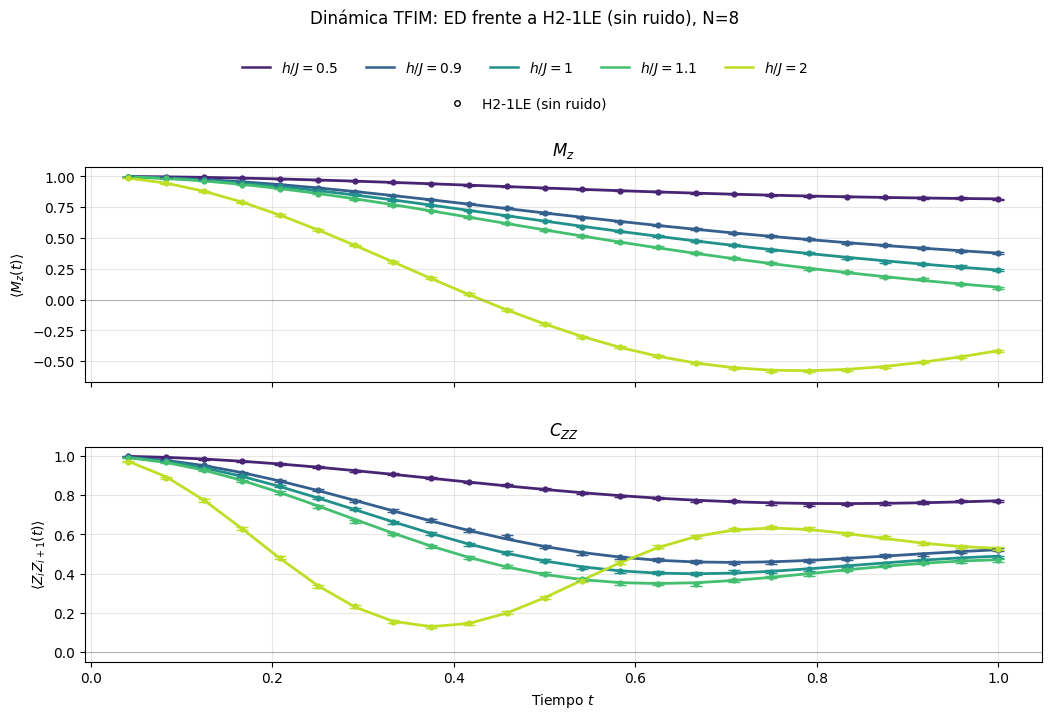

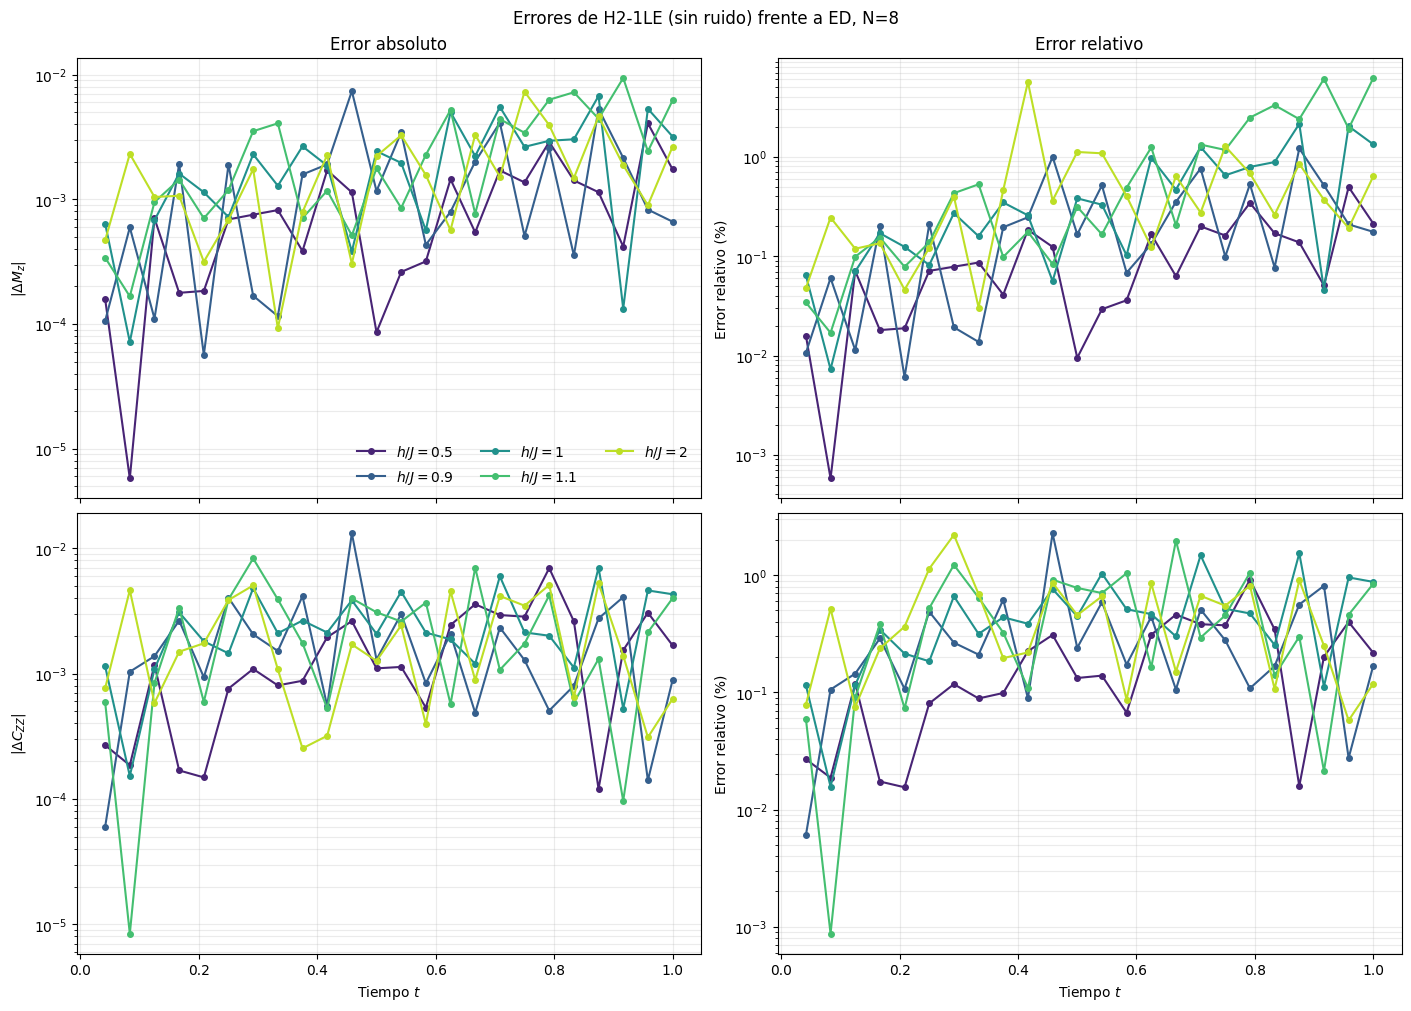

Resultados guardados en: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/h2-dynamics-n8-s25/2026_07_24-02_46_47/dynamics_observables.csv


,h_over_J,time,observable,ed_value,backend_value,abs_error,relative_error_percent,standard_error
0,0.5,0.041667,mz,0.999134,0.998975,0.000159,0.015884,0.000160
1,0.5,0.041667,mz2,0.998485,0.998206,0.000278,0.027881,0.000280
2,0.5,0.041667,czz,0.998268,0.998000,0.000268,0.026894,0.000323
3,0.5,0.083333,mz,0.996556,0.996550,0.000006,0.000580,0.000294
4,0.5,0.083333,mz2,0.993983,0.993975,0.000008,0.000807,0.000512


In [20]:
# Run sin ruido: emulador ideal H2-1LE.
backend_sin_ruido = qnx.QuantinuumConfig(device_name="H2-1LE")
resultados_sin_ruido = run_tfim_dynamics(
    backend=backend_sin_ruido,
    backend_name="H2-1LE (sin ruido)",
    run_label="h2-dynamics-n8-s25",
    force_new=False,
)
resultados_sin_ruido.head()

Reutilizando ejecución H2-1E (con ruido): /home/manugomez/Documents/quantathon/quanthathon/qnexus_runs/h2-1e-dynamics-n8-s25/2026_07_24-03_50_46


Recuperando resultados: 100%|██████████| 120/120 [00:04<00:00, 28.86resultado/s]


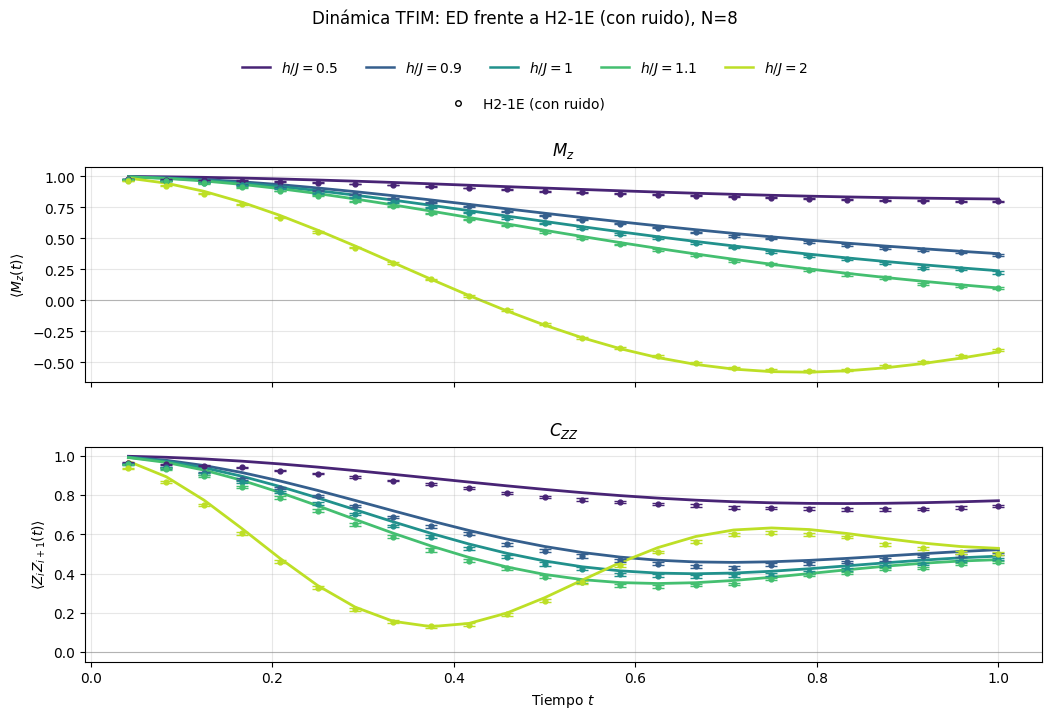

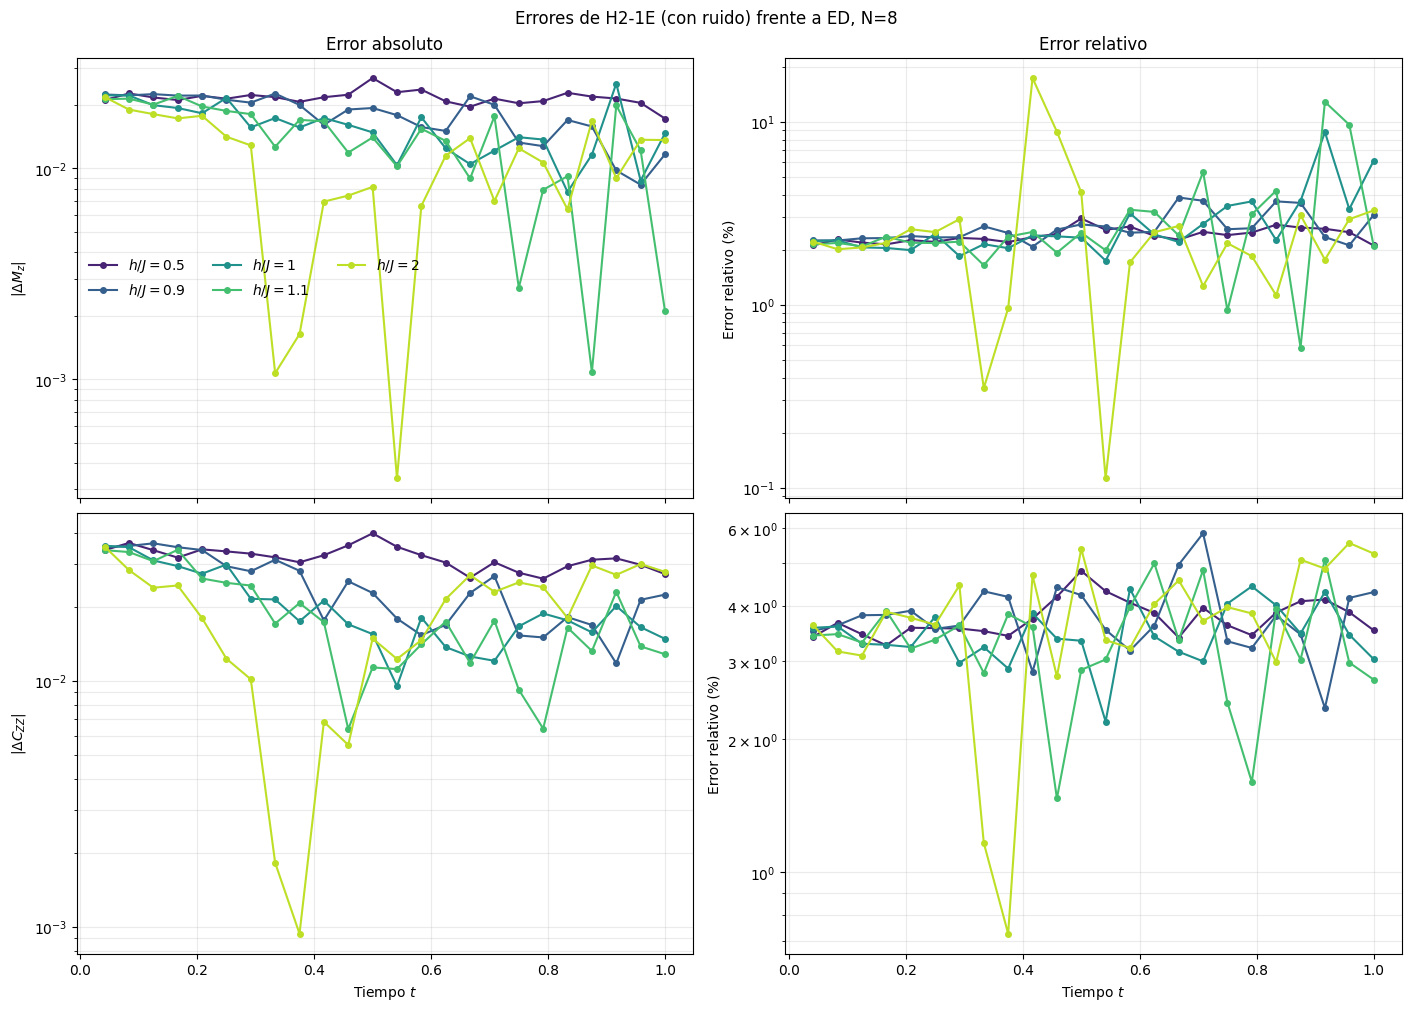

Resultados guardados en: /home/manugomez/Documents/quantathon/quanthathon/qnexus_runs/h2-1e-dynamics-n8-s25/2026_07_24-03_50_46/dynamics_observables.csv


,h_over_J,time,observable,ed_value,backend_value,abs_error,relative_error_percent,standard_error
0,0.5,0.041667,mz,0.999134,0.978050,0.021084,2.110198,0.000868
1,0.5,0.041667,mz2,0.998485,0.964113,0.034372,3.442430,0.001379
2,0.5,0.041667,czz,0.998268,0.964257,0.034011,3.407033,0.001365
3,0.5,0.083333,mz,0.996556,0.973875,0.022681,2.275917,0.000947
4,0.5,0.083333,mz2,0.993983,0.957394,0.036589,3.681076,0.001492


In [19]:
# Run con ruido: emulador H2-1E.
backend_con_ruido = qnx.QuantinuumConfig(device_name="H2-Emulator")
resultados_con_ruido = run_tfim_dynamics(
    backend=backend_con_ruido,
    backend_name="H2-1E (con ruido)",
    run_label="h2-1e-dynamics-n8-s25",
    force_new=False,
)
resultados_con_ruido.head()

## 9) Convergencia de Trotter

ED frente a un backend de Quantinuum en $t=1$, $2.5$ y $5$. El backend se recibe como argumento y los observables se estiman con shots.


In [15]:
def submit_or_resume_convergence_scan(
    circuits,
    scan_records,
    backend,
    backend_name,
    project,
    run_label,
    n_shots=DYNAMICS_SHOTS,
    optimisation_level=2,
    force_new=False,
):
    run_directory = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    if run_directory is not None:
        execute_path = run_directory / "execute-job"
        compile_path = run_directory / "compile-job"
        if execute_path.exists():
            execute_job = qnx.filesystem.load(path=execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución {backend_name} recuperada: {run_directory}")
            return run_directory
        if compile_path.exists():
            compile_job = qnx.filesystem.load(path=compile_path)
            qnx.jobs.wait_for(compile_job)
            compiled_circuits = [
                result.get_output()
                for result in qnx.jobs.results(compile_job)
            ]
            execute_job = qnx.start_execute_job(
                programs=compiled_circuits,
                backend_config=backend,
                n_shots=[n_shots] * len(compiled_circuits),
                name=f"{run_label}-execute-{run_directory.name}",
                project=project,
            )
            save_job_reference(execute_job, execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución {backend_name} reanudada: {run_directory}")
            return run_directory

    if len(circuits) != len(scan_records):
        raise ValueError(
            f"Se recibieron {len(circuits)} circuitos y "
            f"{len(scan_records)} registros."
        )
    if not circuits:
        raise ValueError("No hay circuitos para ejecutar.")

    run_suffix = datetime.datetime.now().strftime(
        "%Y_%m_%d-%H_%M_%S_%f"
    )
    run_directory = prepare_run_directory(
        run_label,
        run_suffix,
        scan_records,
    )
    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(circuits, scan_records, strict=True),
            total=len(circuits),
            desc=f"Subiendo circuitos {backend_name}",
            unit="circuito",
        )
    ]

    compile_job = qnx.start_compile_job(
        programs=circuit_refs,
        backend_config=backend,
        optimisation_level=optimisation_level,
        name=f"{run_label}-compile-{run_suffix}",
        project=project,
    )
    save_job_reference(compile_job, run_directory / "compile-job")
    qnx.jobs.wait_for(compile_job)
    compiled_circuits = [
        result.get_output()
        for result in qnx.jobs.results(compile_job)
    ]

    execute_job = qnx.start_execute_job(
        programs=compiled_circuits,
        backend_config=backend,
        n_shots=[n_shots] * len(compiled_circuits),
        name=f"{run_label}-execute-{run_suffix}",
        project=project,
    )
    save_job_reference(execute_job, run_directory / "execute-job")
    qnx.jobs.wait_for(execute_job)
    print(f"Ejecución {backend_name} guardada: {run_directory}")
    return run_directory


trotter_step_values = np.array(
    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
)
convergence_hj_ratios = np.array([0.5, 1.0, 2.0])
convergence_times = np.array([1.0, 2.5, 5.0])
convergence_n = 8
convergence_J = 1.0
CONVERGENCE_SHOTS = 10_000


def generate_convergence_scan(run_label, force_new=False):
    saved_run = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    if saved_run is not None and (
        (saved_run / "compile-job").exists()
        or (saved_run / "execute-job").exists()
    ):
        return [], []

    circuits = []
    records = []
    for trotter_steps in tqdm(
        trotter_step_values,
        desc="Generando circuitos de convergencia",
        unit="steps",
    ):
        step_circuits, step_records, _ = generate_tfim_trotter_scan(
            hj_ratios=convergence_hj_ratios,
            times=convergence_times,
            J=convergence_J,
            steps=int(trotter_steps),
            n=convergence_n,
            measure=True,
            name_prefix=f"{run_label}-s{int(trotter_steps)}",
        )
        circuits.extend(step_circuits)
        records.extend(step_records)
    return circuits, records


### Resultados de convergencia

Construcción del DataFrame y gráficas para cualquier backend con resultados empíricos.


In [16]:
def build_convergence_dataframe(run_directory, csv_path):
    if csv_path.exists():
        print(f"Usando resultados guardados: {csv_path}")
        return pd.read_csv(csv_path)

    execution_records = recover_execution_records(run_directory)
    rows = []
    for record in execution_records:
        sim_values, standard_errors = z_observables_from_empirical_result(
            record["backend_result"], convergence_n
        )
        sim_mz, sim_mz2, sim_czz = map(float, sim_values)
        se_mz, se_mz2, se_czz = map(float, standard_errors)
        exact_values = exact_reference_observables(
            h=record["ratio"] * convergence_J,
            J=convergence_J,
            t=record["time"],
            n=convergence_n,
        )
        rows.append(
            {
                "h_over_J": record["ratio"],
                "time": record["time"],
                "trotter_steps": record["steps"],
                "dt": record["dt"],
                "sim_mz": sim_mz,
                "exact_mz": exact_values["mz"],
                "abs_error_mz": abs(sim_mz - exact_values["mz"]),
                "se_mz": se_mz,
                "sim_mz2": sim_mz2,
                "exact_mz2": exact_values["mz2"],
                "abs_error_mz2": abs(sim_mz2 - exact_values["mz2"]),
                "se_mz2": se_mz2,
                "sim_czz": sim_czz,
                "exact_czz": exact_values["czz"],
                "abs_error_czz": abs(sim_czz - exact_values["czz"]),
                "se_czz": se_czz,
            }
        )

    dataframe = (
        pd.DataFrame(rows)
        .sort_values(["time", "h_over_J", "trotter_steps"])
        .reset_index(drop=True)
    )
    dataframe.to_csv(csv_path, index=False)
    return dataframe


def plot_trotter_errors(
    convergence_df,
    x_column,
    x_label,
    title_suffix,
    backend_name,
):
    figure, axes = plt.subplots(
        2,
        len(convergence_times),
        figsize=(14, 9),
        sharex=True,
        sharey="row",
        constrained_layout=True,
    )
    error_specs = [
        ("abs_error_mz", r"$|\Delta M_z|$"),
        ("abs_error_czz", r"$|\Delta C_{ZZ}|$"),
    ]
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(convergence_hj_ratios))
    )

    for column, time in enumerate(convergence_times):
        time_data = convergence_df[
            np.isclose(convergence_df["time"], time)
        ]
        for row, (error_column, ylabel) in enumerate(error_specs):
            axis = axes[row, column]
            for color, ratio in zip(colors, convergence_hj_ratios):
                ratio_data = time_data[
                    np.isclose(time_data["h_over_J"], ratio)
                ].sort_values(x_column)
                axis.loglog(
                    ratio_data[x_column],
                    np.maximum(
                        ratio_data[error_column],
                        np.finfo(float).tiny,
                    ),
                    color=color,
                    marker="o",
                    linewidth=1.5,
                    label=fr"$h/J={ratio:.3g}$",
                )
            if row == 0:
                axis.set_title(fr"$t={time:g}$")
            if column == 0:
                axis.set_ylabel(ylabel)
            if row == len(error_specs) - 1:
                axis.set_xlabel(x_label)
            axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].legend(frameon=False)
    figure.suptitle(
        f"Convergencia de Trotter {title_suffix}: "
        f"ED vs {backend_name}, N={convergence_n}"
    )
    return figure, axes


def run_trotter_convergence(
    backend,
    backend_name,
    run_label,
    *,
    force_new=False,
):
    circuits, records = generate_convergence_scan(
        run_label, force_new=force_new
    )
    run_directory = submit_or_resume_convergence_scan(
        circuits=circuits,
        scan_records=records,
        backend=backend,
        backend_name=backend_name,
        project=project,
        run_label=run_label,
        n_shots=CONVERGENCE_SHOTS,
        force_new=force_new,
    )
    csv_path = run_directory / "trotter_convergence.csv"
    dataframe = build_convergence_dataframe(run_directory, csv_path)

    plot_trotter_errors(
        dataframe,
        x_column="dt",
        x_label=r"$\Delta t$",
        title_suffix=r"frente a $\Delta t$",
        backend_name=backend_name,
    )
    plt.show()
    plot_trotter_errors(
        dataframe,
        x_column="trotter_steps",
        x_label=r"Pasos de Trotter $n$",
        title_suffix=r"frente al número de pasos $n$",
        backend_name=backend_name,
    )
    plt.show()
    print(f"Resultados guardados en: {csv_path}")
    return dataframe


Ejecución H2-1LE (sin ruido) recuperada: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-h2-1le-n8-v1/2026_07_24-03_09_44_605091
Usando resultados guardados: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-h2-1le-n8-v1/2026_07_24-03_09_44_605091/trotter_convergence.csv


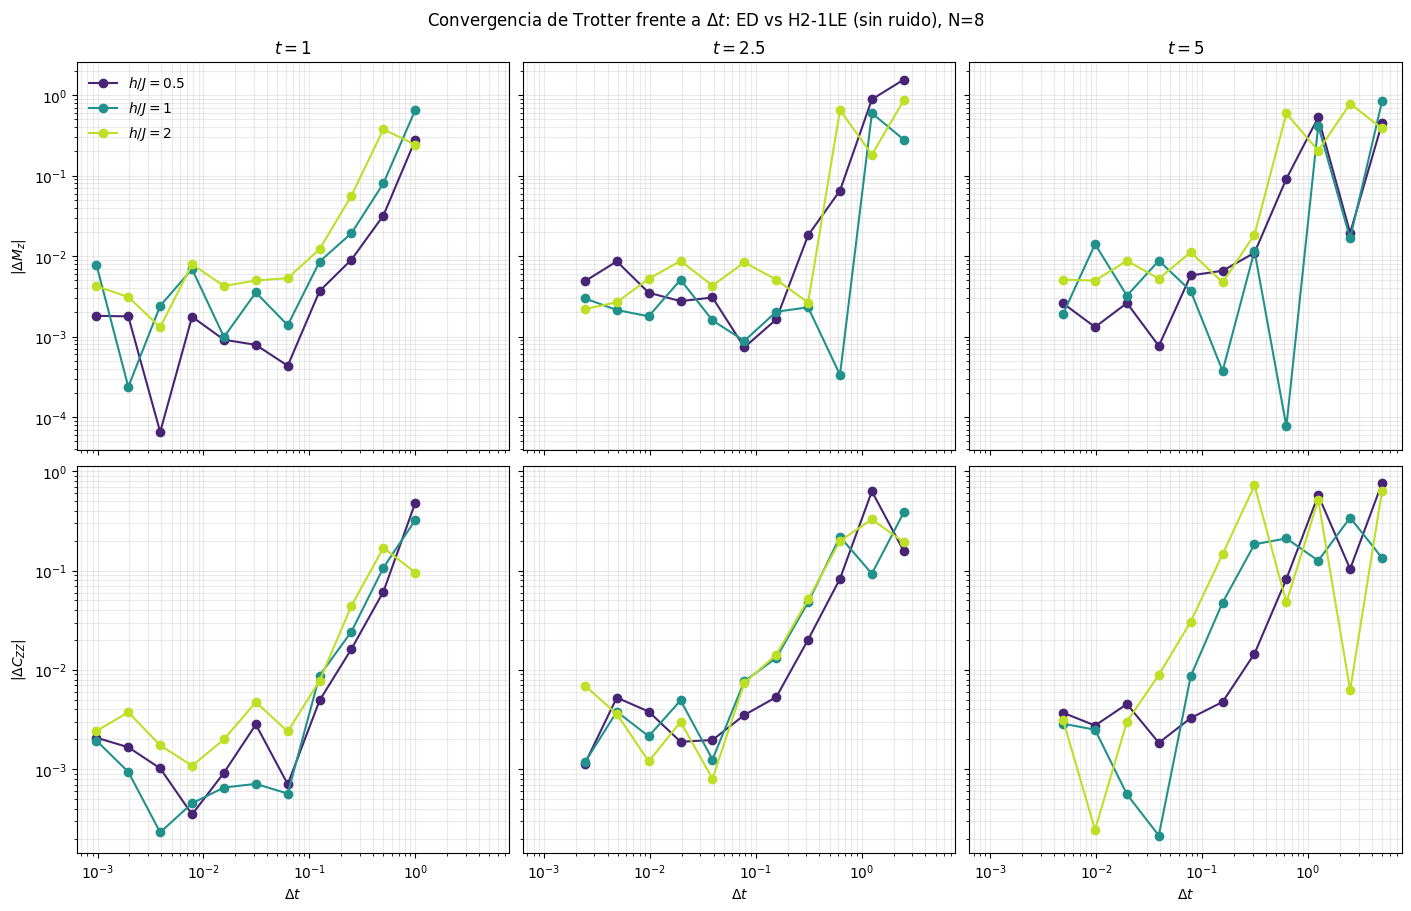

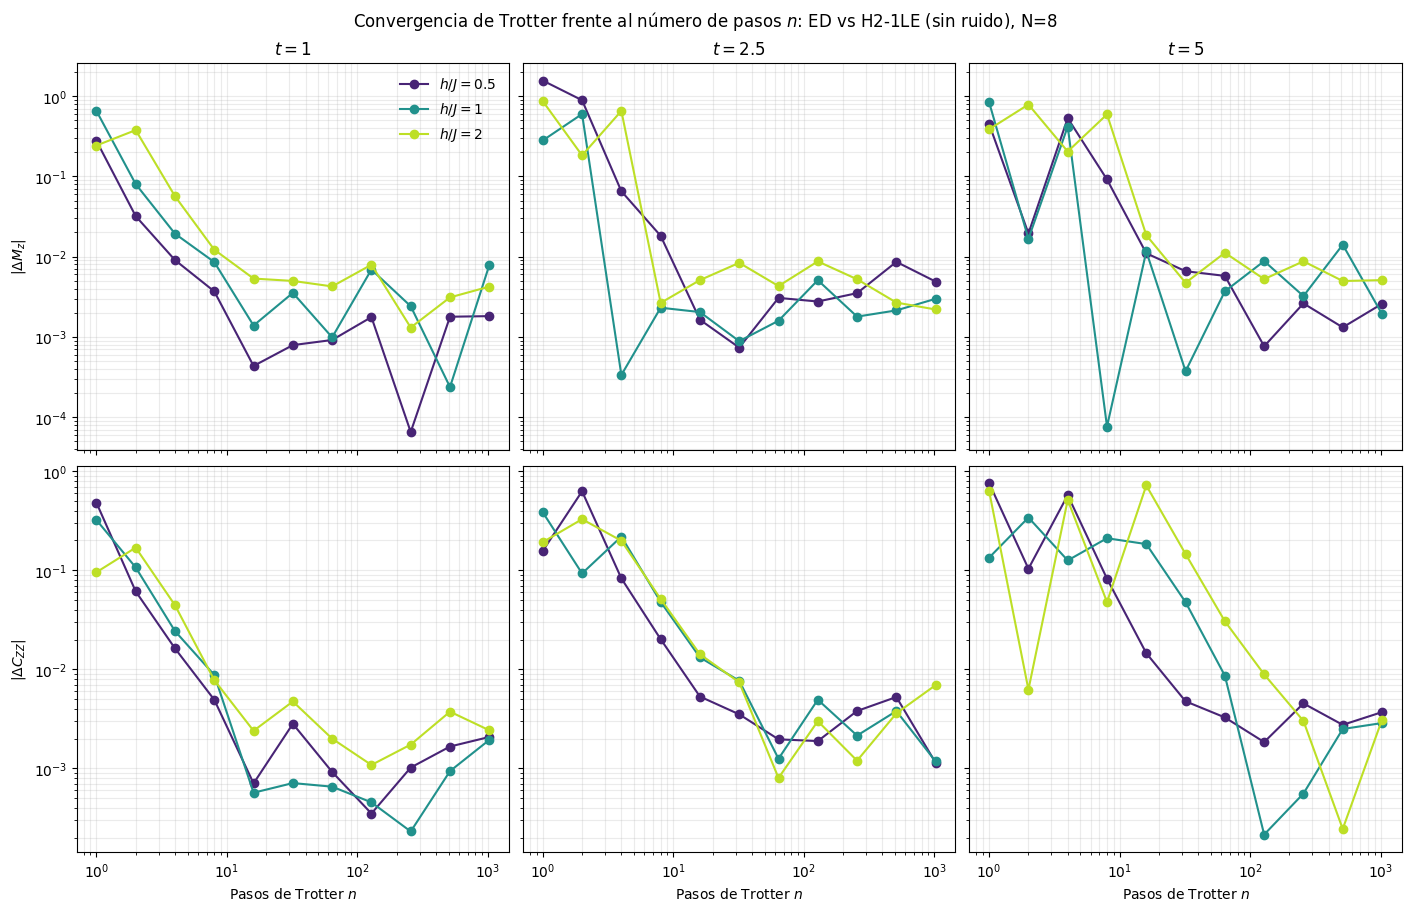

Resultados guardados en: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-h2-1le-n8-v1/2026_07_24-03_09_44_605091/trotter_convergence.csv


,h_over_J,time,trotter_steps,dt,sim_mz,exact_mz,abs_error_mz,se_mz,sim_mz2,exact_mz2,abs_error_mz2,se_mz2,sim_czz,exact_czz,abs_error_czz,se_czz
0,0.5,1.0,1,1.0000,0.539750,0.81759,0.277840,0.002977,0.379925,0.725233,0.345308,0.003044,0.290314,0.771564,0.481249,0.004256
1,0.5,1.0,2,0.5000,0.785625,0.81759,0.031965,0.002455,0.677494,0.725233,0.047739,0.003273,0.710314,0.771564,0.061249,0.003225
2,0.5,1.0,4,0.2500,0.808525,0.81759,0.009065,0.002423,0.712394,0.725233,0.012839,0.003235,0.755286,0.771564,0.016278,0.002992
3,0.5,1.0,8,0.1250,0.813900,0.81759,0.003690,0.002408,0.720413,0.725233,0.004820,0.003237,0.766629,0.771564,0.004935,0.002929
4,0.5,1.0,16,0.0625,0.818025,0.81759,0.000435,0.002382,0.725906,0.725233,0.000673,0.003208,0.770857,0.771564,0.000707,0.002903


In [17]:
# Convergencia de Trotter sin ruido: H2-1LE.
backend_trotter_sin_ruido = qnx.QuantinuumConfig(
    device_name="H2-1LE"
)
convergencia_h2_1le = run_trotter_convergence(
    backend=backend_trotter_sin_ruido,
    backend_name="H2-1LE (sin ruido)",
    run_label="trotter-convergence-h2-1le-n8-v1",
    force_new=False,
)
convergencia_h2_1le.head()

In [237]:
# Convergencia de Trotter con ruido: H2-Emulator.
backend_trotter_con_ruido = qnx.QuantinuumConfig(
    device_name="H2-Emulator"
)
convergencia_h2_emulator = run_trotter_convergence(
    backend=backend_trotter_con_ruido,
    backend_name="H2-Emulator (con ruido)",
    run_label="trotter-convergence-h2-emulator-n8-v1",
    force_new=False,
)
convergencia_h2_emulator.head()

KeyboardInterrupt: 

## 10) Coste físico y exposición acumulada a fallos

Esta sección estudia cómo escala el circuito de evolución de Trotter con el tamaño del sistema. Para comparar circuitos equivalentes se fijan $J=1$, $h/J=1$, $t=5$ y 25 pasos de Trotter, mientras que el número de qubits $N$ varía entre 4 y 20.

Cada circuito se compila para `H2-Emulator` con nivel de optimización 2 antes de medir su profundidad y contar las compuertas de uno y dos qubits. Las operaciones de medida, barrera, *reset* y colapso no se consideran compuertas cuánticas.

Sean $N_1$ y $N_2$ el número de compuertas compiladas de uno y dos qubits, respectivamente. Utilizando las probabilidades de fallo publicadas para H2, $P_1=2.90\times10^{-5}$ y $P_2=1.28\times10^{-3}$, se calcula la probabilidad de exposición a fallos de compuerta

$$
P_{\mathrm{exp}}
=
1-(1-P_1)^{N_1}(1-P_2)^{N_2}.
$$

Bajo la hipótesis de fallos independientes, $P_{\mathrm{exp}}$ representa la probabilidad de que durante la ejecución del circuito ocurra al menos un fallo de compuerta. Dado que el número de compuertas aumenta con el tamaño del sistema, esta cantidad proporciona una medida de cómo crece la exposición acumulada al ruido a medida que se incrementa el número de qubits.

Es importante destacar que $P_{\mathrm{exp}}$ no cuantifica el error de un observable ni la fidelidad de la simulación. Un fallo puede no afectar el observable de interés, introducir únicamente una fase global o tener un efecto parcialmente compensado por otros errores. En consecuencia, esta métrica debe interpretarse como un indicador del coste físico y de la vulnerabilidad del circuito frente al ruido, y no como una estimación directa del error de simulación.

La influencia efectiva del ruido se evalúa posteriormente mediante la comparación entre la evolución ideal y la evolución con ruido, utilizando los observables físicos del sistema. De este modo, $P_{\mathrm{exp}}$ caracteriza la tendencia del circuito a sufrir eventos de fallo conforme aumenta $N$, mientras que la comparación entre simulaciones ideal y ruidosa cuantifica el impacto real de dichos fallos sobre los resultados obtenidos.

In [250]:
COST_BACKEND_NAME = "H2-Emulator"
COST_RUN_LABEL = "h2-emulator-trotter-cost-n4-20-r1-t5-s25-v1"
COST_HJ_RATIO = 1.0
COST_TIME = 5.0
COST_J = 1.0
COST_TROTTER_STEPS = 25
COST_QUBIT_VALUES = np.arange(4, 21, dtype=int)

cost_backend_config = qnx.QuantinuumConfig(
    device_name=COST_BACKEND_NAME,
)
saved_cost_run = latest_run_directory(
    COST_RUN_LABEL,
    required=False,
)
has_saved_cost_compile = (
    saved_cost_run is not None
    and (saved_cost_run / "compile-job").exists()
)

if has_saved_cost_compile:
    cost_run_dir = saved_cost_run
    print(
        f"Reutilizando compilación {COST_BACKEND_NAME}: "
        f"{cost_run_dir}"
    )
else:
    cost_suffix = datetime.datetime.now().strftime(
        "%Y_%m_%d-%H_%M_%S_%f"
    )
    cost_circuits = []
    cost_records = []

    for index, n_qubits in enumerate(COST_QUBIT_VALUES):
        circuit = build_trotter_circuit(
            h=COST_HJ_RATIO * COST_J,
            J=COST_J,
            t=COST_TIME,
            steps=COST_TROTTER_STEPS,
            n_qbits=int(n_qubits),
        )
        circuit.measure_all()
        name = (
            f"tfim-cost-h2e-n{int(n_qubits)}-"
            f"{cost_suffix}-{index}"
        )
        cost_circuits.append(circuit)
        cost_records.append(
            {
                "index": index,
                "trotter_steps": COST_TROTTER_STEPS,
                "h_over_J": COST_HJ_RATIO,
                "time": COST_TIME,
                "J": COST_J,
                "n": int(n_qubits),
                "name": name,
            }
        )

    cost_run_dir = prepare_run_directory(
        COST_RUN_LABEL,
        cost_suffix,
        cost_records,
    )
    cost_circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
            project=project,
        )
        for circuit, record in tqdm(
            zip(cost_circuits, cost_records, strict=True),
            total=len(cost_circuits),
            desc=f"Subiendo circuitos de coste {COST_BACKEND_NAME}",
            unit="circuito",
        )
    ]
    cost_compile_job = qnx.start_compile_job(
        programs=cost_circuit_refs,
        backend_config=cost_backend_config,
        optimisation_level=2,
        name=f"{COST_RUN_LABEL}-compile-{cost_suffix}",
        project=project,
    )
    save_job_reference(
        cost_compile_job,
        cost_run_dir / "compile-job",
    )
    print(
        f"Compilación {COST_BACKEND_NAME} enviada: {cost_run_dir}"
    )


Reutilizando compilación H2-Emulator: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/h2-emulator-trotter-cost-n4-20-r1-t5-s25-v1/2026_07_24-06_18_01_363822


Recuperando circuitos compilados:   0%|          | 0/17 [00:00<?, ?circuito/s]

Resultados guardados en: /Users/anotherdev/workspace/quanthathon/project/h2_emulator_trotter_cost_and_error_floor.csv


,qubits,one_qubit_gates,two_qubit_gates,gate_fault_lower_bound,gate_fault_lower_bound_percent,compiled_depth,two_qubit_gate_types,multi_qubit_gates,trotter_steps
0,4,151,75,0.095561,9.556,103,ZZPhase=75,0,25
1,5,201,100,0.125332,12.533,105,ZZPhase=100,0,25
2,6,251,125,0.154123,15.412,107,ZZPhase=125,0,25
3,7,301,150,0.181967,18.197,109,ZZPhase=150,0,25
4,8,351,175,0.208893,20.889,111,ZZPhase=175,0,25
5,9,401,200,0.234934,23.493,113,ZZPhase=200,0,25
6,10,451,225,0.260117,26.012,115,ZZPhase=225,0,25
7,11,501,250,0.284472,28.447,117,ZZPhase=250,0,25
8,12,551,275,0.308024,30.802,119,ZZPhase=275,0,25
9,13,601,300,0.330802,33.080,121,ZZPhase=300,0,25


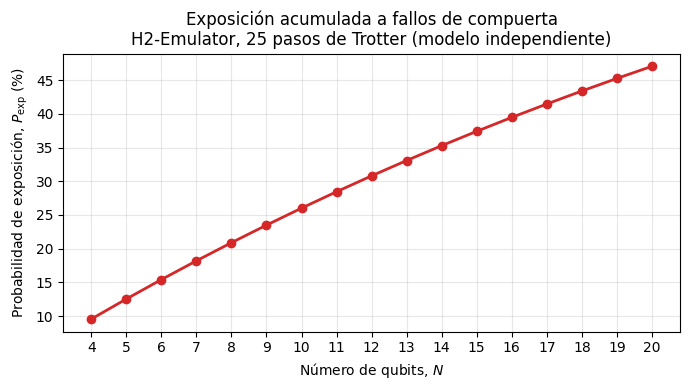

In [251]:
from collections import Counter

from IPython.display import display
from pytket.circuit import OpType


IGNORED_COST_OPERATIONS = {
    OpType.Barrier,
    OpType.Collapse,
    OpType.Measure,
    OpType.Reset,
}
H2_ONE_QUBIT_FAULT_PROBABILITY = 2.90e-5
H2_TWO_QUBIT_FAULT_PROBABILITY = 1.28e-3


def gate_fault_lower_bound(one_qubit_gates, two_qubit_gates):
    """Probabilidad de al menos un fallo de puerta independiente."""
    n1 = int(one_qubit_gates)
    n2 = int(two_qubit_gates)
    if n1 < 0 or n2 < 0:
        raise ValueError("Los conteos de compuertas deben ser no negativos.")
    return 1.0 - (
        (1.0 - H2_ONE_QUBIT_FAULT_PROBABILITY) ** n1
        * (1.0 - H2_TWO_QUBIT_FAULT_PROBABILITY) ** n2
    )


def compiled_circuit_metrics(circuit):
    wire_depth = {qubit: 0 for qubit in circuit.qubits}
    one_qubit_gates = 0
    two_qubit_gates = 0
    multi_qubit_gates = 0
    two_qubit_gate_types = Counter()

    for command in circuit.get_commands():
        if command.op.type in IGNORED_COST_OPERATIONS:
            continue

        qubits = list(command.qubits)
        if not qubits:
            continue

        layer = 1 + max(wire_depth[qubit] for qubit in qubits)
        for qubit in qubits:
            wire_depth[qubit] = layer

        arity = len(qubits)
        if arity == 1:
            one_qubit_gates += 1
        elif arity == 2:
            two_qubit_gates += 1
            operation_name = getattr(
                command.op.type,
                "name",
                str(command.op.type),
            )
            two_qubit_gate_types[operation_name] += 1
        else:
            multi_qubit_gates += 1

    return {
        "compiled_depth": max(wire_depth.values(), default=0),
        "one_qubit_gates": one_qubit_gates,
        "two_qubit_gates": two_qubit_gates,
        "multi_qubit_gates": multi_qubit_gates,
        "two_qubit_gate_types": ", ".join(
            f"{gate}={count}"
            for gate, count in sorted(two_qubit_gate_types.items())
        ),
    }


cost_compile_job = qnx.filesystem.load(
    path=cost_run_dir / "compile-job"
)
cost_job_status = qnx.jobs.status(cost_compile_job)
cost_status_value = getattr(
    cost_job_status.status,
    "value",
    str(cost_job_status.status),
)
if cost_status_value != "COMPLETED":
    raise RuntimeError(
        f"La compilación está en estado {cost_status_value}. "
        "Vuelve a ejecutar esta celda cuando termine."
    )

cost_records = load_scan_records(cost_run_dir)
cost_result_refs = qnx.jobs.results(cost_compile_job)
if len(cost_result_refs) != len(cost_records):
    raise RuntimeError(
        f"Se encontraron {len(cost_result_refs)} circuitos compilados "
        f"para {len(cost_records)} registros."
    )

compiled_cache_dir = cost_run_dir / "compiled_cache"
compiled_cache_dir.mkdir(exist_ok=True)
compiled_cost_circuits = []

for index, result_ref in enumerate(
    tqdm(
        cost_result_refs,
        desc="Recuperando circuitos compilados",
        unit="circuito",
    )
):
    cache_path = compiled_cache_dir / f"{index:04d}.json"
    if cache_path.exists():
        compiled_circuit = Circuit.from_dict(
            json.loads(cache_path.read_text(encoding="utf-8"))
        )
    else:
        compiled_circuit_ref = result_ref.get_output()
        compiled_circuit = compiled_circuit_ref.download_circuit()
        temporary_path = cache_path.with_suffix(".tmp")
        temporary_path.write_text(
            json.dumps(compiled_circuit.to_dict()),
            encoding="utf-8",
        )
        temporary_path.replace(cache_path)
    compiled_cost_circuits.append(compiled_circuit)

cost_rows = []
for record, compiled_circuit in zip(
    cost_records,
    compiled_cost_circuits,
    strict=True,
):
    metrics = compiled_circuit_metrics(compiled_circuit)
    if metrics["multi_qubit_gates"]:
        raise RuntimeError(
            "La compilación produjo compuertas de más de dos qubits."
        )
    fault_floor = gate_fault_lower_bound(
        metrics["one_qubit_gates"],
        metrics["two_qubit_gates"],
    )
    cost_rows.append(
        {
            "qubits": int(record["n"]),
            "trotter_steps": int(record["trotter_steps"]),
            **metrics,
            "gate_fault_lower_bound": fault_floor,
            "gate_fault_lower_bound_percent": 100.0 * fault_floor,
        }
    )

trotter_cost_df = (
    pd.DataFrame(cost_rows)
    .sort_values("qubits")
    .reset_index(drop=True)
    .reindex(
        columns=[
            "qubits",
            "one_qubit_gates",
            "two_qubit_gates",
            "gate_fault_lower_bound",
            "gate_fault_lower_bound_percent",
            "compiled_depth",
            "two_qubit_gate_types",
            "multi_qubit_gates",
            "trotter_steps",
        ]
    )
)
trotter_cost_csv_path = (
    Path.cwd() / "h2_emulator_trotter_cost_and_error_floor.csv"
)
trotter_cost_df.to_csv(trotter_cost_csv_path, index=False)
print(f"Resultados guardados en: {trotter_cost_csv_path}")
display(
    trotter_cost_df.style.format(
        {
            "gate_fault_lower_bound": "{:.6f}",
            "gate_fault_lower_bound_percent": "{:.3f}",
        }
    )
)

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    trotter_cost_df["qubits"],
    trotter_cost_df["gate_fault_lower_bound_percent"],
    marker="o",
    linewidth=2,
    color="tab:red",
)
axis.set_xlabel(r"Número de qubits, $N$")
axis.set_ylabel(r"Probabilidad de exposición, $P_{\mathrm{exp}}$ (%)")
axis.set_title(
    "Exposición acumulada a fallos de compuerta\n"
    "H2-Emulator, 25 pasos de Trotter (modelo independiente)"
)
axis.set_xticks(COST_QUBIT_VALUES)
axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()


## 11) Estado fundamental del TFIM con VQE

Para cada valor de $h/J$ buscamos parámetros $\theta$ que minimicen

$$
E(\theta)=
\langle\psi(\theta)|H_{\mathrm{TFIM}}|\psi(\theta)\rangle,
\qquad
|\psi(\theta)\rangle=U(\theta)|\psi(0)\rangle.
$$

El ansatz simbólico $U(\theta)$ y el Hamiltoniano se definen manualmente en la
siguiente celda. Después, COBYLA evalúa la energía ejecutando los circuitos de
medida en `H2-1LE` con 500 shots. Los mejores parámetros de un valor de $h/J$
se reutilizan como punto inicial del siguiente.

Al terminar cada optimización, el circuito óptimo se ejecuta con 10 000 shots
para calcular la energía, $M_z$, $M_z^2$, $M_x$ y $C_{ZZ}$. Los resultados se
guardan progresivamente y se comparan con la diagonalización exacta del
mismo sistema finito de $N=8$ qubits y fronteras abiertas. Esta referencia
no corresponde al límite termodinámico.


> **Referencia de implementación**
>
> Quantinuum Nexus, [VQE workflow using Quantinuum Nexus](https://docs.quantinuum.com/nexus/trainings/notebooks/knowledge_articles/vqe_example.html).
>
> El flujo de sustitución de parámetros, construcción de circuitos de medida,
> compilación, ejecución en `H2-1LE` y optimización con COBYLA está adaptado de
> este ejemplo oficial.


In [17]:
from pytket import Circuit
from sympy import symbols
from pytket.utils.operators import QubitPauliOperator,  Qubit
from pytket.pauli import Pauli, QubitPauliString



def build_vqe_ansatz(n: int) -> Circuit:
    """Devuelve tu circuito simbólico U(theta)|psi(0)>."""
    # Define aquí el ansatz y sus símbolos.
    # Debe devolverse un pytket.Circuit con al menos un símbolo libre.

    gamma, beta = symbols("gamma beta")
    c = Circuit(n)
    for q in range(n-1):
        c.ZZPhase(gamma, q, q+1)
    for q in range(n):
        c.Rx(beta, q)
    return c






def build_vqe_hamiltonian(
    h: float,
    J: float,
    n: int,
) -> QubitPauliOperator:
    """Devuelve tu Hamiltoniano TFIM para los valores indicados."""
    # Define aquí el QubitPauliOperator que se minimizará.
    terms = {}

    for i in range(n - 1):
        zz_string = QubitPauliString(
            {
                Qubit(i): Pauli.Z,
                Qubit(i + 1): Pauli.Z,
            }
        )
        terms[zz_string] = -float(J)

    for i in range(n):
        x_string = QubitPauliString(
            {
                Qubit(i): Pauli.X,
            }
        )
        terms[x_string] = -float(h)

    return QubitPauliOperator(terms)


In [ ]:
import datetime
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qnexus as qnx
from pytket import Circuit
from pytket.circuit import Qubit
from pytket.pauli import Pauli, QubitPauliString
from pytket.utils.operators import QubitPauliOperator
from scipy.optimize import minimize
from scipy.stats import qmc
from sympy import Symbol


# La optimización es local y exacta; Nexus se usa una sola vez al final.
VQE_N = 8
VQE_J = 1.0
VQE_HJ_RATIOS = np.array([0.5, 1.0, 2.0])
# VQE_HJ_RATIOS = np.linspace(0.1, 2.5, 50)
VQE_DEPTH = 4
VQE_STARTS = 8
VQE_MAXITER = 300
VQE_FINAL_SHOTS = 10_000
VQE_RANDOM_SEED = 7
VQE_RUN_LABEL = f"tfim-vqe-hva-p{VQE_DEPTH}-n{VQE_N}-v2"
VQE_BACKEND = qnx.QuantinuumConfig(device_name="H2-1LE")


def _build_tfim_hamiltonian(h: float) -> QubitPauliOperator:
    terms = {}
    for site in range(VQE_N - 1):
        terms[
            QubitPauliString(
                {
                    Qubit(site): Pauli.Z,
                    Qubit(site + 1): Pauli.Z,
                }
            )
        ] = -VQE_J
    for site in range(VQE_N):
        terms[QubitPauliString({Qubit(site): Pauli.X})] = -float(h)
    return QubitPauliOperator(terms)


def _build_hva_ansatz(reference: str):
    if reference not in {"plus", "ghz"}:
        raise ValueError(f"Referencia desconocida: {reference}")

    circuit = Circuit(
        VQE_N,
        name=f"tfim-{reference}-p{VQE_DEPTH}",
    )
    symbols = tuple(
        symbol
        for layer in range(VQE_DEPTH)
        for symbol in (
            Symbol(f"{reference}_gamma_{layer}"),
            Symbol(f"{reference}_beta_{layer}"),
        )
    )

    if reference == "plus":
        for qubit in range(VQE_N):
            circuit.H(qubit)
    else:
        circuit.H(0)
        for qubit in range(VQE_N - 1):
            circuit.CX(qubit, qubit + 1)

    for layer in range(VQE_DEPTH):
        gamma, beta = symbols[2 * layer : 2 * layer + 2]

        # Evita que la primera capa sea sólo una fase global.
        if reference == "ghz":
            for qubit in range(VQE_N):
                circuit.Rx(beta, qubit)

        for qubit in range(VQE_N - 1):
            circuit.ZZPhase(gamma, qubit, qubit + 1)

        if reference == "plus":
            for qubit in range(VQE_N):
                circuit.Rx(beta, qubit)

    return circuit, symbols


def _bind_circuit(symbolic_circuit, symbols, parameters):
    parameters = np.asarray(parameters, dtype=float)
    if parameters.shape != (len(symbols),):
        raise ValueError("Número incorrecto de parámetros VQE.")
    if not np.all(np.isfinite(parameters)):
        raise ValueError("Los parámetros VQE deben ser finitos.")

    circuit = symbolic_circuit.copy()
    circuit.symbol_substitution(
        dict(zip(symbols, parameters, strict=True))
    )
    if circuit.free_symbols():
        raise RuntimeError("Quedaron símbolos libres en el circuito.")
    return circuit


def _statevector_energy(
    symbolic_circuit,
    symbols,
    parameters,
    hamiltonian,
):
    state = _bind_circuit(
        symbolic_circuit,
        symbols,
        parameters,
    ).get_statevector()
    return float(
        np.real_if_close(hamiltonian.state_expectation(state))
    )


def _optimise_reference(
    ratio: float,
    reference: str,
    warm_start=None,
):
    symbolic_circuit, symbols = _build_hva_ansatz(reference)
    hamiltonian = _build_tfim_hamiltonian(ratio * VQE_J)
    parameter_count = len(symbols)

    seed = (
        VQE_RANDOM_SEED
        + int(round(1000 * ratio))
        + (100_000 if reference == "ghz" else 0)
    )
    sobol_power = int(np.ceil(np.log2(VQE_STARTS)))
    sobol_starts = qmc.Sobol(
        d=parameter_count,
        scramble=True,
        seed=seed,
    ).random_base2(sobol_power)[:VQE_STARTS]

    starts = [np.zeros(parameter_count)]
    if warm_start is not None:
        starts.append(np.asarray(warm_start, dtype=float))
    starts.extend(2.0 * sobol_starts - 1.0)

    def objective(parameters):
        return _statevector_energy(
            symbolic_circuit,
            symbols,
            parameters,
            hamiltonian,
        )

    runs = []
    for initial_parameters in starts:
        runs.append(
            minimize(
                objective,
                initial_parameters,
                method="L-BFGS-B",
                bounds=[(-1.0, 1.0)] * parameter_count,
                options={
                    "maxiter": VQE_MAXITER,
                    "ftol": 1e-11,
                    "gtol": 1e-7,
                    "maxls": 50,
                },
            )
        )

    finite_runs = [run for run in runs if np.isfinite(run.fun)]
    if not finite_runs:
        raise RuntimeError(
            f"No hubo solución finita para {ratio=}, {reference=}."
        )

    best = min(finite_runs, key=lambda run: float(run.fun))
    parameters = np.asarray(best.x, dtype=float)
    energy = objective(parameters)
    return {
        "reference": reference,
        "symbolic_circuit": symbolic_circuit,
        "symbols": symbols,
        "parameters": parameters,
        "local_energy": energy,
        "optimizer_success": bool(best.success),
        "optimizer_evaluations": int(sum(run.nfev for run in runs)),
        "optimizer_message": str(best.message),
    }


def _build_exact_hamiltonian_vqe(h: float) -> np.ndarray:
    """Misma diagonalización densa usada en exact.ipynb."""
    x = np.array([[0, 1], [1, 0]], dtype=complex)
    z = np.array([[1, 0], [0, -1]], dtype=complex)
    operator = lambda pauli, site: np.kron(
        np.eye(2**site),
        np.kron(pauli, np.eye(2 ** (VQE_N - site - 1))),
    )
    zero = np.zeros((2**VQE_N, 2**VQE_N), dtype=complex)
    hx = -h * sum(
        (operator(x, site) for site in range(VQE_N)), start=zero
    )
    hzz = -VQE_J * sum(
        (
            operator(z, site) @ operator(z, site + 1)
            for site in range(VQE_N - 1)
        ),
        start=zero,
    )
    return hx + hzz


def _exact_ground_state_values(ratio: float):
    eigenvalues, eigenvectors = np.linalg.eigh(
        _build_exact_hamiltonian_vqe(float(ratio * VQE_J))
    )
    ground_state = eigenvectors[:, 0]
    probabilities = np.abs(ground_state) ** 2
    basis = np.arange(2**VQE_N, dtype=np.uint64)
    positions = np.arange(VQE_N, dtype=np.uint64)
    bits = ((basis[:, None] >> positions) & 1).astype(int)
    z_values = 1 - 2 * bits
    mz_values = np.mean(z_values, axis=1)
    czz_values = np.mean(
        z_values[:, :-1] * z_values[:, 1:], axis=1
    )

    mx = 0.0
    for qubit in range(VQE_N):
        flipped = (basis ^ np.uint64(1 << qubit)).astype(int)
        mx += float(
            np.real(np.vdot(ground_state, ground_state[flipped]))
        )
    mx /= VQE_N

    return {
        "ed_energy": float(eigenvalues[0]),
        "ed_mz": float(probabilities @ mz_values),
        "ed_mz2": float(probabilities @ (mz_values**2)),
        "ed_mx": float(mx),
        "ed_czz": float(probabilities @ czz_values),
    }


def _sample_statistics(backend_result, basis: str):
    counts = (
        backend_result
        .get_empirical_distribution()
        .as_counter()
    )
    total_shots = int(sum(counts.values()))
    if total_shots < 2:
        raise ValueError("Se requieren al menos dos shots.")

    values = []
    weights= []
    for bitstring, count in counts.items():
        spins = 1 - 2 * np.asarray(tuple(bitstring), dtype=int)
        if basis == "z":
            mz = float(np.mean(spins))
            sample = np.array(
                [
                    mz,
                    mz**2,
                    np.mean(spins[:-1] * spins[1:]),
                ],
                dtype=float,
            )
        elif basis == "x":
            sample = np.array([np.mean(spins)], dtype=float)
        else:
            raise ValueError(f"Base desconocida: {basis}")
        values.append(sample)
        weights.append(int(count))

    values = np.asarray(values)
    weights = np.asarray(weights, dtype=float)
    means = np.average(values, axis=0, weights=weights)
    centered = values - means
    variances = np.sum(
        weights[:, None] * centered**2,
        axis=0,
    ) / (total_shots - 1)
    errors = np.sqrt(
        np.maximum(variances, 0.0) / total_shots
    )
    return means, errors



VQE_FORCE_RERUN = False


def _resolve_vqe_results_path() -> Path:
    filename = f"{VQE_RUN_LABEL}-results.csv"
    local_path = Path.cwd() / filename
    project_path = Path.cwd() / "project" / filename
    if local_path.exists() or not project_path.exists():
        return local_path
    return project_path


VQE_RESULTS_PATH = _resolve_vqe_results_path()
VQE_REQUIRED_COLUMNS = {
    "h_over_J",
    "reference",
    "depth",
    "vqe_energy",
    "vqe_mz2",
    "vqe_mx",
    "ed_mz2",
    "ed_mx",
    "se_mz2",
    "se_mx",
    "abs_error_energy",
}


def _load_cached_vqe_results(path: Path):
    if not path.exists():
        return None

    cached = pd.read_csv(path)
    missing = VQE_REQUIRED_COLUMNS.difference(cached.columns)
    if missing:
        print(
            f"Caché VQE ignorada: faltan columnas {sorted(missing)}."
        )
        return None

    expected_ratios = np.sort(
        np.asarray(VQE_HJ_RATIOS, dtype=float)
    )
    cached = cached.sort_values("h_over_J").reset_index(drop=True)
    cached_ratios = cached["h_over_J"].to_numpy(dtype=float)
    same_ratios = (
        cached_ratios.shape == expected_ratios.shape
        and np.allclose(
            cached_ratios,
            expected_ratios,
            rtol=0.0,
            atol=1e-12,
        )
    )
    same_depth = (
        cached["depth"].nunique() == 1
        and int(cached["depth"].iloc[0]) == VQE_DEPTH
    )
    if not same_ratios or not same_depth:
        print(
            "Caché VQE ignorada: la malla h/J o la profundidad "
            "no coincide con la configuración actual."
        )
        return None

    optional_checks = {
        "n_qubits": VQE_N,
        "coupling_J": VQE_J,
        "shots": VQE_FINAL_SHOTS,
    }
    for column, expected in optional_checks.items():
        if (
            column in cached
            and not np.allclose(cached[column], expected)
        ):
            print(
                f"Caché VQE ignorada: {column} no coincide."
            )
            return None
    return cached


def _compute_vqe_results():
    ratios = sorted(float(value) for value in VQE_HJ_RATIOS)
    candidates = {}

    # Cada referencia se continúa desde la fase donde es exacta.
    for reference, ordered_ratios in (
        ("plus", list(reversed(ratios))),
        ("ghz", ratios),
    ):
        warm_start = None
        for ratio in ordered_ratios:
            candidate = _optimise_reference(
                ratio,
                reference,
                warm_start,
            )
            candidates[reference, ratio] = candidate
            warm_start = candidate["parameters"]
            print(
                f"Local h/J={ratio:g}, {reference}: "
                f"E={candidate['local_energy']:.9f}, "
                f"success={candidate['optimizer_success']}"
            )

    chosen = {}
    exact_values = {}
    for ratio in ratios:
        chosen[ratio] = min(
            (
                candidates["plus", ratio],
                candidates["ghz", ratio],
            ),
            key=lambda item: item["local_energy"],
        )
        exact_values[ratio] = _exact_ground_state_values(ratio)

        if (
            chosen[ratio]["local_energy"]
            < exact_values[ratio]["ed_energy"] - 1e-8
        ):
            raise RuntimeError(
                f"Violación variacional para h/J={ratio:g}."
            )

        print(
            f"Elegido h/J={ratio:g}: "
            f"{chosen[ratio]['reference']}, "
            f"E={chosen[ratio]['local_energy']:.9f}, "
            f"ED={exact_values[ratio]['ed_energy']:.9f}"
        )


    # Dos circuitos por ratio: Z obtiene Mz, Mz² y Czz; X obtiene Mx.
    manifest = []
    measurement_circuits = []
    for ratio in ratios:
        candidate = chosen[ratio]
        state_prep = _bind_circuit(
            candidate["symbolic_circuit"],
            candidate["symbols"],
            candidate["parameters"],
        )

        z_circuit = state_prep.copy()
        z_circuit.measure_all()

        x_circuit = state_prep.copy()
        for qubit in range(VQE_N):
            x_circuit.H(qubit)
        x_circuit.measure_all()

        for basis, circuit in (("z", z_circuit), ("x", x_circuit)):
            manifest.append({"ratio": ratio, "basis": basis})
            measurement_circuits.append(circuit)


    # Un solo upload batch, un compile y un execute en Nexus/H2-1LE.
    project = qnx.projects.get_or_create(name="VQE-TFIM-H2-1LE")
    qnx.context.set_active_project(project)
    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    run_id = f"{VQE_RUN_LABEL}-{timestamp}"

    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=(
                f"{run_id}-r{record['ratio']:g}-"
                f"{record['basis']}"
            ),
            project=project,
        )
        for circuit, record in zip(
            measurement_circuits,
            manifest,
            strict=True,
        )
    ]

    compiled_refs = qnx.compile(
        programs=circuit_refs,
        backend_config=VQE_BACKEND,
        optimisation_level=2,
        name=f"{run_id}-compile",
        project=project,
        timeout=None,
    )

    backend_results = qnx.execute(
        programs=compiled_refs,
        n_shots=[VQE_FINAL_SHOTS] * len(compiled_refs),
        backend_config=VQE_BACKEND,
        name=f"{run_id}-execute",
        project=project,
        timeout=None,
    )

    if len(backend_results) != len(manifest):
        raise RuntimeError("Nexus devolvió un número inesperado de resultados.")

    result_map = {
        (record["ratio"], record["basis"]): result
        for record, result in zip(
            manifest,
            backend_results,
            strict=True,
        )
    }


    rows = []
    for ratio in ratios:
        z_means, z_errors = _sample_statistics(
            result_map[ratio, "z"],
            "z",
        )
        x_means, x_errors = _sample_statistics(
            result_map[ratio, "x"],
            "x",
        )
        mz, mz2, czz = (float(value) for value in z_means)
        mz_error, mz2_error, czz_error = (
            float(value) for value in z_errors
        )
        mx = float(x_means[0])
        mx_error = float(x_errors[0])
        h = ratio * VQE_J
        energy = (
            -VQE_J * (VQE_N - 1) * czz
            -h * VQE_N * mx
        )
        energy_error = float(
            np.hypot(
                VQE_J * (VQE_N - 1) * czz_error,
                h * VQE_N * mx_error,
            )
        )

        candidate = chosen[ratio]
        row = {
            "h_over_J": ratio,
            "reference": candidate["reference"],
            "depth": VQE_DEPTH,
            "n_qubits": VQE_N,
            "coupling_J": VQE_J,
            "shots": VQE_FINAL_SHOTS,
            "backend": "H2-1LE",
            "parameters": json.dumps(
                candidate["parameters"].tolist()
            ),
            "optimizer_energy": candidate["local_energy"],
            "optimizer_success": candidate["optimizer_success"],
            "optimizer_evaluations": (
                candidate["optimizer_evaluations"]
            ),
            "vqe_energy": float(energy),
            "vqe_mz": mz,
            "vqe_mz2": mz2,
            "vqe_mx": mx,
            "vqe_czz": czz,
            "se_energy": energy_error,
            "se_mz": mz_error,
            "se_mz2": mz2_error,
            "se_mx": mx_error,
            "se_czz": czz_error,
            **exact_values[ratio],
        }
        row["abs_error_energy"] = abs(
            row["vqe_energy"] - row["ed_energy"]
        )
        rows.append(row)

    vqe_df = pd.DataFrame(rows).sort_values(
        "h_over_J"
    ).reset_index(drop=True)

    vqe_df.to_csv(VQE_RESULTS_PATH, index=False)
    print(f"Resultados guardados en {VQE_RESULTS_PATH}")
    return vqe_df





vqe_df = (
    None
    if VQE_FORCE_RERUN
    else _load_cached_vqe_results(VQE_RESULTS_PATH)
)
if vqe_df is None:
    vqe_df = _compute_vqe_results()
else:
    print(
        f"Caché VQE cargada desde {VQE_RESULTS_PATH}; "
        "no se repiten la optimización ni la ejecución en H2-1LE."
    )



vqe_df = vqe_df.sort_values("h_over_J").reset_index(drop=True)

phase_figure, phase_axis = plt.subplots(figsize=(9, 5))
phase_axis.plot(
    vqe_df["h_over_J"],
    vqe_df["ed_mz2"],
    color="tab:blue",
    linewidth=2.5,
    marker="o",
    markerfacecolor="white",
    label=r"ED $N=8$: $\langle M_z^2\rangle$",
)
phase_axis.plot(
    vqe_df["h_over_J"],
    vqe_df["ed_mx"],
    color="tab:orange",
    linestyle="--",
    linewidth=2.5,
    marker="s",
    markerfacecolor="white",
    label=r"ED $N=8$: $\langle M_x\rangle$",
)
phase_axis.errorbar(
    vqe_df["h_over_J"],
    vqe_df["vqe_mz2"],
    yerr=vqe_df["se_mz2"],
    fmt="o",
    markersize=7,
    capsize=3,
    color="tab:blue",
    markeredgecolor="white",
    label=r"VQE: $\langle M_z^2\rangle$",
    zorder=3,
)
phase_axis.errorbar(
    vqe_df["h_over_J"],
    vqe_df["vqe_mx"],
    yerr=vqe_df["se_mx"],
    fmt="s",
    markersize=7,
    capsize=3,
    color="tab:orange",
    markeredgecolor="white",
    label=r"VQE: $\langle M_x\rangle$",
    zorder=3,
)
phase_axis.set_xlabel(r"Razón $h/J$")
phase_axis.set_ylabel("Valor esperado")
phase_axis.set_title(
    f"VQE frente a diagonalización exacta, "
    f"N={VQE_N}, p={VQE_DEPTH}"
)
phase_axis.set_xlim(
    vqe_df["h_over_J"].min() - 0.1,
    vqe_df["h_over_J"].max() + 0.1,
)
phase_axis.set_ylim(-0.02, 1.03)
phase_axis.grid(alpha=0.25)
phase_axis.legend(frameon=False, ncol=2)
phase_figure.tight_layout()
plt.show()


vqe_df


## 12) Comparación directa: Trotter ideal frente a Trotter con ruido

Esta sección utiliza **exclusivamente los dos CSV ya guardados**. No genera circuitos, no recupera trabajos de QNexus y no vuelve a ejecutar simulaciones. Las 99 filas de cada backend se emparejan por $h/J$, tiempo, pasos de Trotter y $\Delta t$.

Para cada observable se comparan:

$$
E_{\mathrm{ideal}}=|O_{\mathrm{ideal}}-O_{\mathrm{ED}}|,
\qquad
E_{\mathrm{ruidoso}}=|O_{\mathrm{ruidoso}}-O_{\mathrm{ED}}|,
$$

y el efecto incremental del ruido

$$
\Delta O_{\mathrm{ruido}}=O_{\mathrm{ruidoso}}-O_{\mathrm{ideal}},
\qquad
\mathrm{SE}_{\Delta}=\sqrt{\mathrm{SE}_{\mathrm{ideal}}^2+\mathrm{SE}_{\mathrm{ruidoso}}^2}.
$$

Las curvas muestran la media sobre las nueve combinaciones de campo y tiempo para cada número de pasos. Las bandas representan el rango intercuartílico entre esas condiciones, no un intervalo de confianza.


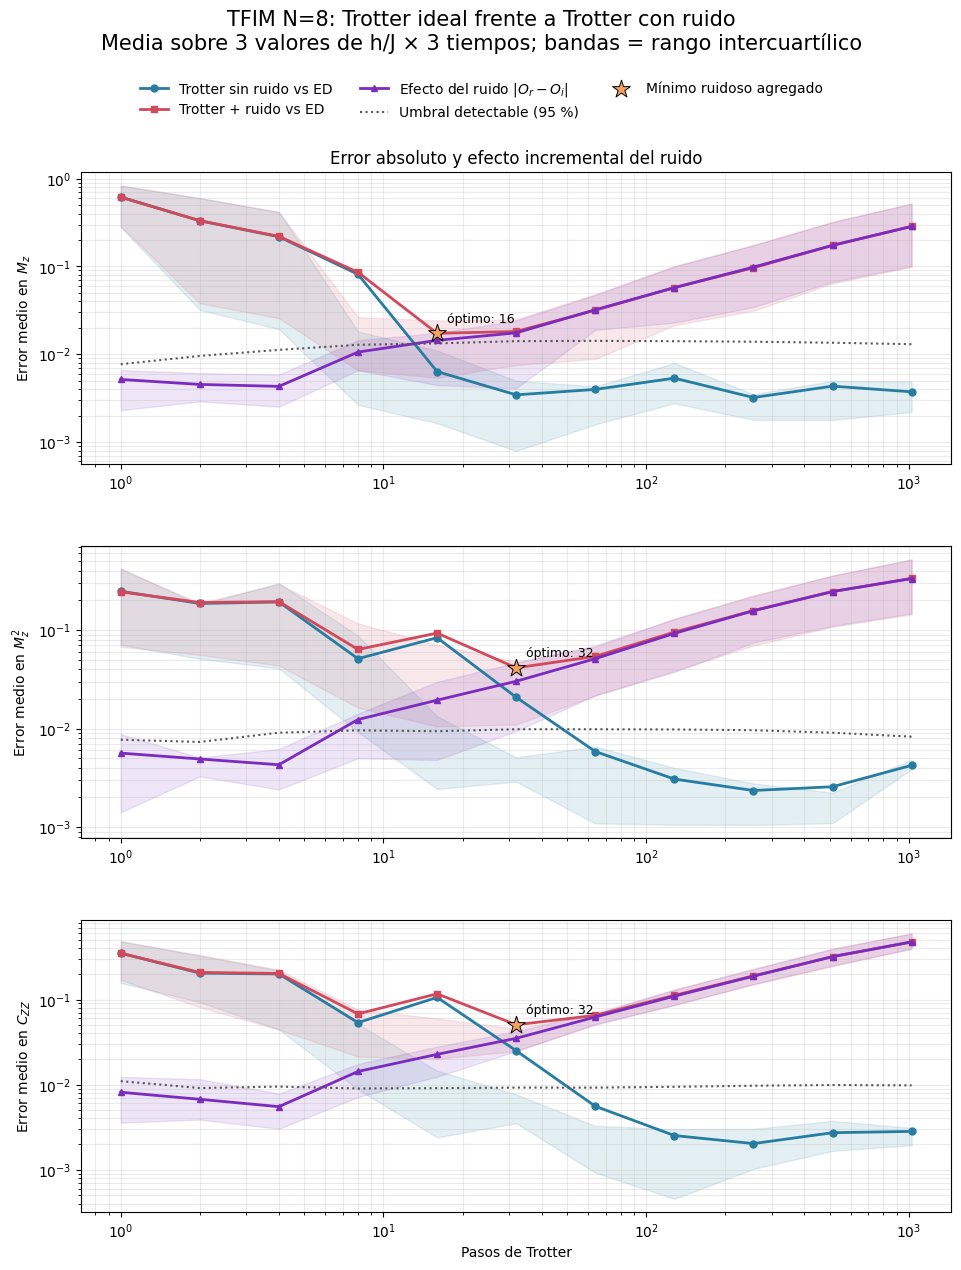

In [28]:
import importlib
import plot_trotter_noise_comparison as trotter_noise_plot

trotter_noise_plot = importlib.reload(trotter_noise_plot)

trotter_noise_paired = trotter_noise_plot.load_paired_results()
trotter_noise_summary = trotter_noise_plot.summarize_by_step(
    trotter_noise_paired
)
trotter_noise_summary.to_csv(
    trotter_noise_plot.SUMMARY_PATH,
    index=False,
)

trotter_noise_figure, trotter_noise_axes = (
    trotter_noise_plot.plot_comparison(
    trotter_noise_summary
    )
)
trotter_noise_figure.savefig(
    trotter_noise_plot.FIGURE_PATH,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

